In [1]:
from Node import Node
import torch
import faiss
import os
import pickle
from LLM.qwen3_vl_embedding import Qwen3VLEmbedder
from PIL import Image
import matplotlib.pyplot as plt

#file_paths
DIR_PATH = "2-Build_Graph"
BASE_PATH = ""
g4_path = "2-Build_Graph/data/g4.pkl"
faiss_path = os.path.join(DIR_PATH, "data", "embeddings_hnsw.faiss")
embedding_processed_ids_path = f"{DIR_PATH}/data/embedding_processed_ids.txt"

with open(embedding_processed_ids_path, "r", encoding="utf-8") as f:
    embedding_processed_ids_list = [line.strip() for line in f if line.strip()]

index = faiss.read_index(faiss_path)

#load new data to embed

with open(g4_path, "rb") as f:
    nodes = pickle.load(f)
for node in nodes.values():
    if node.node_type in ["S", "A", "T", "V", "H"]:
        if node.node_id not in embedding_processed_ids_list:
            print(node.node_id)

c:\Users\HP\Desktop\Projects\MMNodeRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
model = Qwen3VLEmbedder(model_name_or_path="Qwen/Qwen3-VL-Embedding-2B")

Using device: cuda


c:\Users\HP\Desktop\Projects\MMNodeRAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--Qwen--Qwen3-VL-Embedding-2B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 625/625 [00:00<00:00, 7008.49it/s]


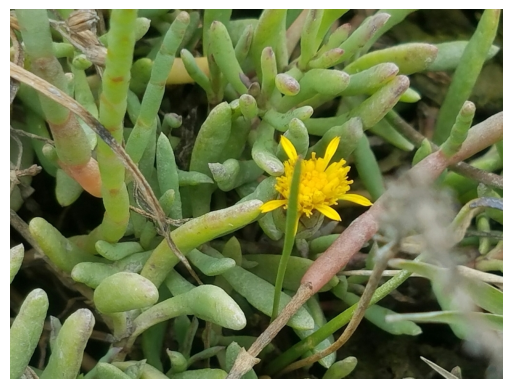

In [3]:
def format_query(q = None, img = None):
    return [{"text": q, "image": img, "instruction": "Retrieve images or text relevant to the user's query.",}]
query = "What is the closest parent taxonomy of this plant?"
img = "InfoSeek/oven_images_sampled/oven_00574081.jpg"
query_embedding = model.process(format_query(query,img)).to(torch.float32).cpu().numpy()

img = Image.open(img)
plt.imshow(img)
plt.axis("off")
plt.show()

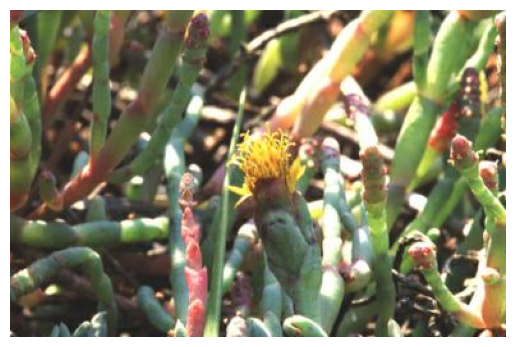

Rank: 0
0.6029496
------------------------------
Jaumea carnosa, also known as marsh jaumea or fleshy jaumea, is a perennial, halophytic salt marsh plant native to the western coast of North America. A member of the sunflower family, it is found in wetlands, salt marshes, and on coastal sea cliffs from British Columbia to northern Baja California, with some populations on the Channel Islands of California. This perennial dicotyledon has succulent green leaves on soft, weak, pinkish-green stems, giving it an appearance similar to ice plant. It produces yellow flower heads, composed of both disc and ray flowers, which sit atop an enlarged peduncle. The plant spreads via an extensive rhizome system.
Rank: 1
0.57336116
------------------------------
Jaumea carnosa, known by the common names marsh jaumea, fleshy jaumea, or simply jaumea, is a halophytic salt marsh plant native to the wetlands, coastal sea cliffs and salt marshes of the western coast of North America.## Description.It is a p

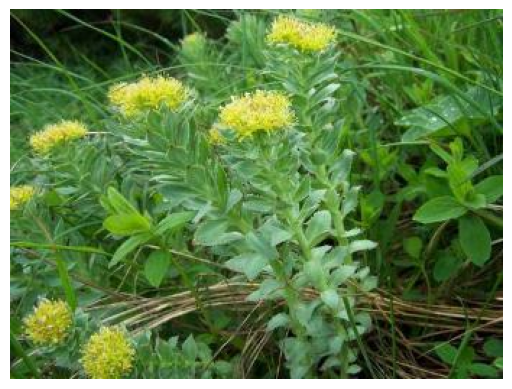

Rank: 3
0.551235
------------------------------


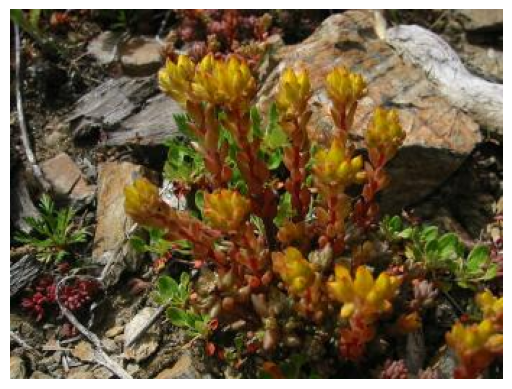

Rank: 4
0.5452624
------------------------------
Sedum lanceolatum, also known as spearleaf stonecrop or lanceleaf stonecrop, is a flowering plant species in the family Crassulaceae native to western North America, including western Canada, the United States (from Alaska to Arizona, New Mexico, South Dakota, and Nebraska).
Rank: 5
0.5226742
------------------------------


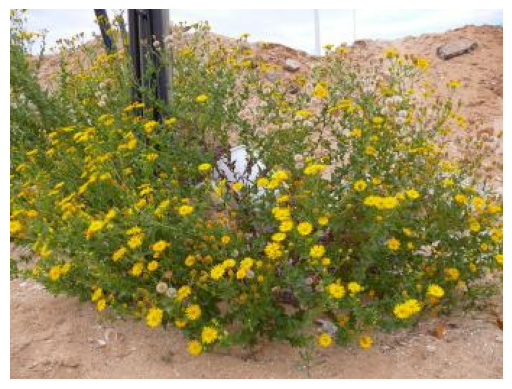

Rank: 6
0.52156425
------------------------------


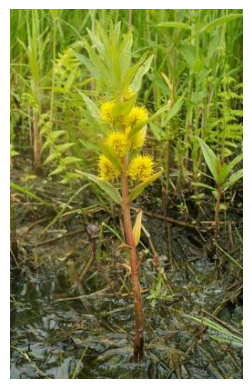

Rank: 7
0.5072299
------------------------------
Pilosella officinarum, also known as mouse-ear hawkweed and synonymously as Hieracium pilosella, is a yellow-flowered species in the daisy family Asteraceae, native to Europe and northern Asia. It produces single, lemon-coloured inflorescences and is a highly variable member of a species complex consisting of dozens of subspecies and hundreds of varieties and forms. It is characterized as an allelopathic plant.
Rank: 8
0.5031441
------------------------------
Gypsophila muralis, also known as annual gypsophila, cushion baby's-breath, or low baby's-breath, is now classified under the genus Psammophiliella.
Rank: 9
0.5002142
------------------------------
Pilosella officinarum (synonym Hieracium pilosella), known as mouse-ear hawkweed, is a yellow-flowered species of flowering plant in the daisy family Asteraceae, native to Europe and northern Asia. It produces single, lemon-coloured inflorescences. Like most hawkweed species, it is highly

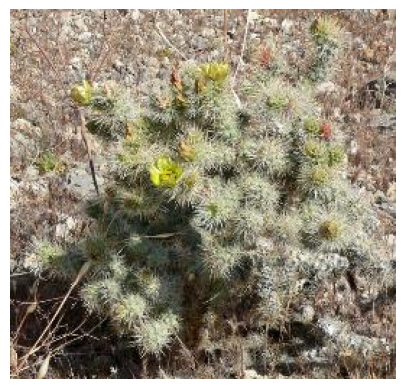

Rank: 14
0.48800796
------------------------------
The list of species in the genus includes Gypsophila acantholimoides, Gypsophila achaia, Gypsophila acutifolia (also known as sharpleaf baby's-breath), Gypsophila adenophora, Gypsophila adenophylla, Gypsophila albida, Gypsophila altissima, Gypsophila antari, Gypsophila antoninae, Gypsophila arabica, Gypsophila aretioides, Gypsophila arrostii (also known as Arrost's baby's-breath), Gypsophila aucheri, Gypsophila aulieatensis, Gypsophila australis, Gypsophila bicolor, Gypsophila capituliflora, Gypsophila caricifolia, Gypsophila cephalotes, Gypsophila davurica, Gypsophila desertorum, Gypsophila elegans (also known as showy baby's-breath), Gypsophila fastigiata (also known as fastigiate gypsophila), Gypsophila glandulosa, Gypsophila glomerata, Gypsophila huashanensis, Gypsophila imbricata, Gypsophila intricata, Gypsophila iranica, Gypsophila krascheninnikovii, Gypsophila libanotica, Gypsophila viscosa, Gypsophila wendelboi, Gypsophila wilh

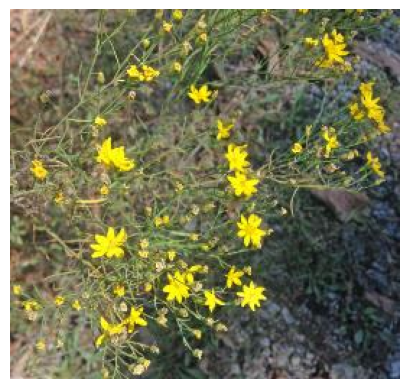

Rank: 20
0.47861677
------------------------------
Jaumea carnosa, also known as marsh jaumea, fleshy jaumea, or jaumea, is a halophytic salt marsh plant native to the wetlands, coastal sea cliffs, and salt marshes of the western coast of North America.
Rank: 21
0.4763647
------------------------------
Thysanocarpus curvipes is a species of flowering plant in the family Brassicaceae, commonly known as sand fringepod and lacepod.
Rank: 22
0.47569424
------------------------------
Pilosella officinarum, commonly known as mouse-ear hawkweed and formerly classified under the synonym Hieracium pilosella, is a hispid perennial plant in the family Asteraceae. Native to Europe and northern Asia, this species is a highly variable member of a complex comprising dozens of subspecies and hundreds of varieties. The plant is characterized by a basal rosette of entire, acute to blunt leaves measuring 1–12 cm in length, which feature a tomentose underside. Excluding the flower parts, the entire plant 

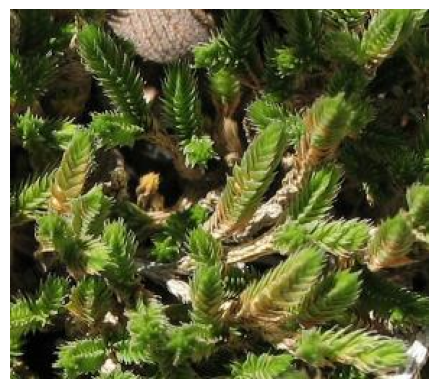

Rank: 27
0.47143298
------------------------------
Gypsophila is a genus of flowering plants in the carnation family, Caryophyllaceae, native to Eurasia, Africa, Australia, and the Pacific Islands.
Rank: 28
0.46980503
------------------------------
Gypsophila is a large and heterogeneous genus of flowering plants within the tribe Caryophylleae of the family Caryophyllaceae, comprising approximately 150 species of annual or perennial herbs. The genus name is derived from the Greek words *gypsos* (gypsum) and *philios* (loving), reflecting the preference of some species for gypsum-rich substrates. Commonly known as baby's-breath or babe's breath, these names specifically refer to the ornamental species *Gypsophila paniculata*, though the term is often applied more broadly. Native to Eurasia, Africa, Australia, and the Pacific Islands, Gypsophila species primarily inhabit mountainous steppes in the north temperate Old World, with a significant diversification hotspot in the Irano-Turanian

In [4]:
k = 32
D, I = index.search(query_embedding, k)
for i in range(k):
    id = embedding_processed_ids_list[I[0][i]]
    if "H" in id:
        continue
    node = nodes[id]

    content = node.content
    if node.node_type != "V":
        print(content)
    else:
        img = Image.open(content)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    print(f"Rank: {i}")
    print(D[0][i])
    print("-"*30)